# Capítulo 33 — Análisis temporal básico

## Mirar los datos según momentos

En los capítulos anteriores trabajamos con distintas formas de resumir datos.

Usamos frecuencias, indicadores numéricos, agrupaciones con `groupby()`, rankings, valores extremos y tablas dinámicas con `pivot_table()`.

Ahora vamos a dar un paso más: empezar a analizar los datos según una dimensión temporal simple.

En este capítulo vamos a observar cómo cambian algunos indicadores según el día y el horario. Para eso seguiremos usando el dataset `tips`, que ya conocemos.

La idea no será todavía trabajar con fechas completas ni con series temporales avanzadas. En cambio, vamos a usar columnas como `day` y `time` para responder preguntas como:

- ¿en qué días se registraron más cuentas?
- ¿qué días acumularon mayor facturación?
- ¿cómo se distribuyen las cuentas entre `Lunch` y `Dinner`?
- ¿qué diferencias aparecen cuando miramos cantidades, totales y promedios?

También vamos a comenzar a usar gráficos simples para acompañar el análisis. Un gráfico no reemplaza a una tabla, pero puede ayudarnos a ver comparaciones de manera más clara.

## Cargar el dataset de trabajo

Vamos a seguir usando el dataset `tips` de Seaborn. Como ya conocemos sus columnas principales, podemos concentrarnos en el nuevo objetivo del capítulo: analizar la información según días y horarios.

También vamos a importar `matplotlib.pyplot`, porque más adelante usaremos algunos gráficos simples para visualizar los resultados.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


La salida muestra las primeras filas del dataset.

Cada fila representa una cuenta registrada en un restaurante. Entre las columnas disponibles aparecen:

- `total_bill`: importe total de la cuenta.
- `tip`: propina.
- `sex`: sexo de la persona registrada en la cuenta.
- `smoker`: indica si la mesa corresponde a fumadores o no fumadores.
- `day`: día en que se registró la cuenta.
- `time`: momento del día, por ejemplo `Lunch` o `Dinner`.
- `size`: cantidad de personas en la mesa.

Para este capítulo nos van a interesar especialmente las columnas `day` y `time`.

Aunque no son fechas completas, nos permiten hacer un primer análisis temporal básico: observar cómo cambian las cuentas según el día y el horario.

## Variables temporales simples

En análisis de datos, no siempre trabajamos desde el comienzo con fechas completas como día, mes y año. A veces, una primera aproximación temporal puede hacerse con variables más simples.

En este dataset vamos a usar:

- `day`, que indica el día de la semana.
- `time`, que indica si la cuenta corresponde a `Lunch` o `Dinner`.

Estas columnas nos permiten empezar a comparar momentos.

In [ ]:
df[["day", "time", "total_bill", "tip", "size"]].head()

,day,time,total_bill,tip,size
0,Sun,Dinner,16.99,1.01,2
1,Sun,Dinner,10.34,1.66,3
2,Sun,Dinner,21.01,3.50,3
3,Sun,Dinner,23.68,3.31,2
4,Sun,Dinner,24.59,3.61,4


En esta vista reducida aparecen solo las columnas que vamos a usar con más frecuencia en este capítulo.

Las primeras filas corresponden al día `Sun` y al horario `Dinner`. Cada registro incluye el importe total de la cuenta, la propina y el tamaño de la mesa.

A partir de estas columnas podemos empezar a formular preguntas temporales simples.

Por ejemplo, podemos preguntarnos si todas las combinaciones de día y horario tienen la misma cantidad de cuentas, o si algunos momentos aparecen mucho más representados que otros.

## Primera pregunta: ¿cómo se distribuyen las cuentas según día y horario?

Antes de calcular importes totales o promedios, conviene mirar cuántos registros tenemos para cada momento. Esto es importante porque no todos los días y horarios tienen necesariamente la misma cantidad de datos.

Vamos a construir una tabla que muestre la cantidad de cuentas registradas para cada combinación de `day` y `time`.

In [ ]:
tabla_cuentas_dia_horario = df.pivot_table(
    values="total_bill",
    index="day",
    columns="time",
    aggfunc="count",
    observed=True,
    fill_value=0
)

tabla_cuentas_dia_horario

time,Lunch,Dinner
day,,
Thur,61,1
Fri,7,12
Sat,0,87
Sun,0,76


La tabla muestra cuántas cuentas se registraron para cada combinación de día y horario.

Podemos observar que los registros no están distribuidos de manera pareja:

- `Thur` concentra la mayoría de sus cuentas en `Lunch`: 61 cuentas.
- `Fri` tiene registros en ambos horarios: 7 en `Lunch` y 12 en `Dinner`.
- `Sat` aparece solo en `Dinner`, con 87 cuentas.
- `Sun` también aparece solo en `Dinner`, con 76 cuentas.

Esto nos muestra una primera característica temporal del dataset: algunos días están asociados principalmente a un horario.

Antes de comparar importes o promedios, es importante conocer esta distribución de registros. Si un día tiene muchas más cuentas que otro, eso puede influir en los totales que calculemos después.

## El orden temporal importa

En capítulos anteriores usamos ordenamientos para construir rankings. Por ejemplo, podíamos ordenar de mayor a menor para encontrar los días con mayor facturación o las cuentas más altas.

Pero cuando analizamos datos según una dimensión temporal, no siempre conviene ordenar por el valor más grande. Muchas veces necesitamos respetar el orden lógico de los momentos. En este dataset, los días aparecen como categorías. Para analizarlos temporalmente, vamos a definir un orden:

`Thur`, `Fri`, `Sat`, `Sun`

Ese orden nos va a ayudar a leer los resultados como una secuencia de días y no solo como una lista de categorías.

In [ ]:
orden_dias = ["Thur", "Fri", "Sat", "Sun"]

tabla_cuentas_dia_horario = tabla_cuentas_dia_horario.reindex(orden_dias)

tabla_cuentas_dia_horario

time,Lunch,Dinner
day,,
Thur,61,1
Fri,7,12
Sat,0,87
Sun,0,76


La tabla mantiene el mismo aspecto que antes, pero ahora hicimos algo importante: definimos de manera explícita el orden de los días. Esto puede parecer un detalle menor, pero es importante en análisis temporal.

Si estuviéramos construyendo un ranking, podríamos ordenar de mayor a menor según la cantidad de cuentas. Pero en este caso queremos leer los días como una secuencia:

`Thur` → `Fri` → `Sat` → `Sun`

De esta manera, las comparaciones respetan el orden lógico de los momentos que estamos analizando.

## Total facturado por día

Ya vimos cuántas cuentas se registraron en cada combinación de día y horario. Ahora podemos avanzar hacia otra pregunta:

**¿cuánto se facturó en total cada día?**

Para responderla, vamos a agrupar los datos por `day` y calcular tres indicadores:

- cantidad de cuentas;
- total facturado;
- promedio de cuenta.

Estos tres valores nos permiten comparar los días desde perspectivas distintas.

In [ ]:
resumen_dia = df.groupby("day", observed=True).agg(
    cantidad_cuentas=("total_bill", "count"),
    total_facturado=("total_bill", "sum"),
    promedio_cuenta=("total_bill", "mean")
).round(2)

resumen_dia = resumen_dia.reindex(orden_dias)

resumen_dia

,cantidad_cuentas,total_facturado,promedio_cuenta
day,,,
Thur,62,1096.33,17.68
Fri,19,325.88,17.15
Sat,87,1778.40,20.44
Sun,76,1627.16,21.41


La tabla resume tres indicadores por día.

Podemos observar que:

- `Sat` tiene la mayor cantidad de cuentas, con 87 registros.
- `Sun` tiene 76 cuentas, menos que `Sat`, pero presenta el promedio de cuenta más alto: 21.41.
- `Thur` tiene 62 cuentas y un total facturado de 1096.33.
- `Fri` tiene pocos registros en comparación con los demás días: solo 19 cuentas.

Si miramos el total facturado, los valores más altos aparecen en `Sat` y `Sun`. Pero si miramos el promedio de cuenta, `Sun` supera a `Sat`.

Esta diferencia es importante: un día puede facturar mucho porque tiene muchas cuentas, porque sus cuentas son más altas, o por una combinación de ambas cosas.

## Visualizar el total facturado por día

Ahora vamos a representar el total facturado por día con un gráfico de barras. El gráfico no agrega información nueva por sí mismo: usa los mismos datos que ya calculamos en la tabla anterior. Sin embargo, puede ayudarnos a comparar los días de manera más directa.

En este caso vamos a usar el orden temporal que definimos antes:

`Thur`, `Fri`, `Sat`, `Sun`

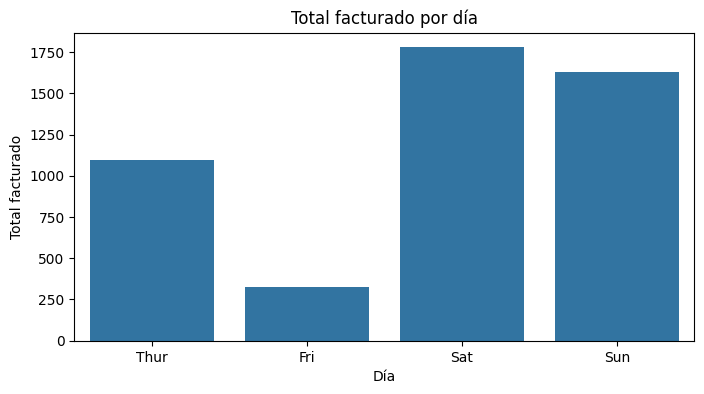

In [ ]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=resumen_dia.reset_index(),
    x="day",
    y="total_facturado"
)

plt.title("Total facturado por día")
plt.xlabel("Día")
plt.ylabel("Total facturado")

plt.show()

El gráfico muestra el total facturado para cada día.

Cada barra representa un día del dataset, y la altura de la barra indica cuánto se facturó en total ese día. Visualmente se observa que `Sat` y `Sun` tienen los valores más altos. `Thur` aparece en un nivel intermedio y `Fri` queda bastante por debajo del resto.

Esto coincide con la tabla anterior:

- `Sat`: 1778.40
- `Sun`: 1627.16
- `Thur`: 1096.33
- `Fri`: 325.88

El gráfico ayuda a ver rápidamente la diferencia entre los días, especialmente la distancia entre `Fri` y los días de fin de semana.

## Cómo se construyó este gráfico

En la celda anterior usamos dos herramientas:

`matplotlib.pyplot`, que importamos como `plt`, y `seaborn`, que importamos como `sns`.

La línea:

```python
plt.figure(figsize=(8, 4))
```

crea el espacio donde se va a dibujar el gráfico.

El argumento `figsize=(8, 4)` indica el tamaño de la figura: 8 unidades de ancho y 4 de alto.

Luego usamos:

```python
sns.barplot(
    data=resumen_dia.reset_index(),
    x="day",
    y="total_facturado"
)
```

Esta instrucción construye un gráfico de barras.

Le indicamos tres cosas principales:

* `data`: la tabla que contiene los datos que vamos a graficar.
* `x`: la columna que se ubicará en el eje horizontal.
* `y`: la columna que se ubicará en el eje vertical.

Usamos `resumen_dia.reset_index()` porque en la tabla `resumen_dia` el día estaba como índice. Para graficarlo con Seaborn, necesitamos que `day` vuelva a estar disponible como una columna común.

Después agregamos un título y etiquetas para los ejes:

```python
plt.title("Total facturado por día")
plt.xlabel("Día")
plt.ylabel("Total facturado")
```

`plt.title()` agrega el título del gráfico.

`plt.xlabel()` define el nombre del eje horizontal.

`plt.ylabel()` define el nombre del eje vertical.

Por último:

```python
plt.show()
```

muestra el gráfico en pantalla.

En general, esta estructura se puede leer así:

1. crear el espacio del gráfico;
2. indicar qué datos se van a graficar;
3. definir qué va en cada eje;
4. agregar título y etiquetas;
5. mostrar el resultado.



## Total facturado y promedio de cuenta

El total facturado es un indicador importante, pero no alcanza por sí solo para interpretar completamente lo que ocurre en cada día. Un día puede tener mucha facturación porque recibió muchas cuentas, aunque el promedio de cada cuenta no sea el más alto. Por eso, ahora vamos a mirar el promedio de cuenta por día. La pregunta cambia:

ya no queremos saber cuánto se facturó en total, sino **cuánto fue, en promedio, el importe de cada cuenta en cada día.**

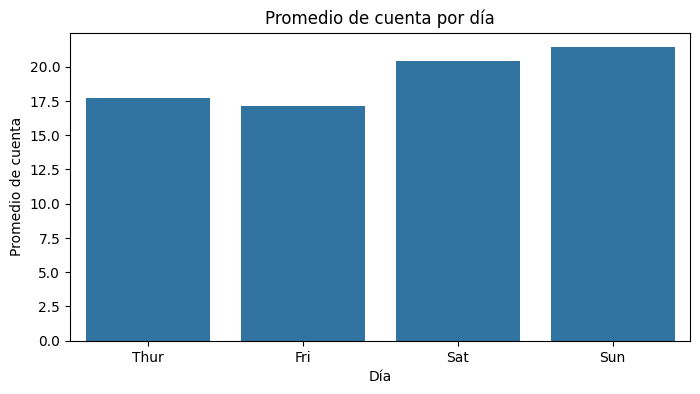

In [ ]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=resumen_dia.reset_index(),
    x="day",
    y="promedio_cuenta"
)

plt.title("Promedio de cuenta por día")
plt.xlabel("Día")
plt.ylabel("Promedio de cuenta")

plt.show()

El gráfico muestra el promedio de cuenta para cada día. A diferencia del gráfico anterior, ahora no estamos mirando cuánto se facturó en total, sino cuánto fue el importe promedio de cada cuenta.

Visualmente se observa que `Sun` tiene el promedio más alto, seguido por `Sat`.

En cambio, `Thur` y `Fri` tienen promedios más bajos y bastante cercanos entre sí.

Esto nos ayuda a distinguir dos ideas:

- `Sat` fue el día con mayor facturación total.
- `Sun` fue el día con mayor promedio de cuenta.

Por eso, en un análisis exploratorio conviene mirar más de un indicador. Si solo observamos el total facturado, podemos perder de vista que otro día tuvo cuentas más altas en promedio.

## Comparar días y horarios al mismo tiempo

Hasta ahora analizamos los días de manera general. Pero el dataset también tiene la columna `time`, que distingue entre `Lunch` y `Dinner`.

Esto nos permite hacer una pregunta más específica:

**¿cómo cambian la cantidad de cuentas, el total facturado y el promedio de cuenta según el día y el horario?**

Para responderla, vamos a agrupar los datos usando dos columnas:

- `day`
- `time`

Este tipo de análisis nos permite observar no solo qué pasa en cada día, sino también en qué momento del día se concentran los registros.

In [ ]:
resumen_dia_horario = df.groupby(["day", "time"], observed=True).agg(
    cantidad_cuentas=("total_bill", "count"),
    total_facturado=("total_bill", "sum"),
    promedio_cuenta=("total_bill", "mean")
).round(2)

resumen_dia_horario

cantidad_cuentas  total_facturado  promedio_cuenta
day  time                                                      
Thur Lunch                 61          1077.55            17.66
     Dinner                 1            18.78            18.78
Fri  Lunch                  7            89.92            12.85
     Dinner                12           235.96            19.66
Sat  Dinner                87          1778.40            20.44
Sun  Dinner                76          1627.16            21.41

La tabla muestra los indicadores agrupados por día y horario.

Podemos observar que la distribución no es pareja:

`Thur` tiene casi todos sus registros en `Lunch`: 61 cuentas. En `Dinner` aparece solo 1 cuenta.

`Fri` tiene registros en ambos horarios: 7 cuentas en `Lunch` y 12 en `Dinner`.

`Sat` y `Sun` aparecen solamente en `Dinner`.

También podemos comparar los importes:

- En `Thur`, el total facturado de `Lunch` es 1077.55.
- En `Fri`, `Dinner` factura más que `Lunch`: 235.96 frente a 89.92.
- En `Sat` y `Sun`, toda la facturación corresponde a `Dinner`.

Hay que tener cuidado con el promedio de `Thur` en `Dinner`. Aunque el promedio es 18.78, ese valor se calcula con una sola cuenta. Por eso no conviene darle la misma importancia que a promedios calculados con muchos registros.

Este es un punto importante del análisis exploratorio: antes de interpretar un promedio, siempre conviene mirar cuántos datos lo sostienen.

## Preparar la tabla para graficar

La tabla anterior tiene dos niveles de índice: `day` y `time`. Eso ocurre porque agrupamos usando dos columnas:

`df.groupby(["day", "time"])`

Este formato es útil para leer la tabla, pero para graficar con Seaborn suele ser más cómodo volver a convertir esos índices en columnas comunes. Para eso vamos a usar `reset_index()`.

De esta manera, `day` y `time` vuelven a quedar como columnas de la tabla, junto con `cantidad_cuentas`, `total_facturado` y `promedio_cuenta`.

In [ ]:
resumen_dia_horario_grafico = resumen_dia_horario.reset_index()

resumen_dia_horario_grafico

,day,time,cantidad_cuentas,total_facturado,promedio_cuenta
0,Thur,Lunch,61,1077.55,17.66
1,Thur,Dinner,1,18.78,18.78
2,Fri,Lunch,7,89.92,12.85
3,Fri,Dinner,12,235.96,19.66
4,Sat,Dinner,87,1778.40,20.44
5,Sun,Dinner,76,1627.16,21.41


La tabla conserva la misma información que antes, pero ahora tiene una estructura más simple para graficar.

Antes, `day` y `time` formaban parte del índice de la tabla.

Ahora aparecen como columnas:

- `day`
- `time`
- `cantidad_cuentas`
- `total_facturado`
- `promedio_cuenta`

Este formato nos permite indicar con más facilidad qué variable queremos ubicar en el eje horizontal, cuál en el eje vertical y cuál usar para separar los grupos.

## Graficar días y horarios

Ahora vamos a construir un gráfico de barras para comparar el total facturado según el día y el horario.

En este gráfico:

- el eje horizontal mostrará los días;
- el eje vertical mostrará el total facturado;
- el color de las barras separará los horarios `Lunch` y `Dinner`.

Para lograr esa separación vamos a usar el argumento `hue`.

En Seaborn, `hue` permite dividir las barras según una segunda variable categórica.

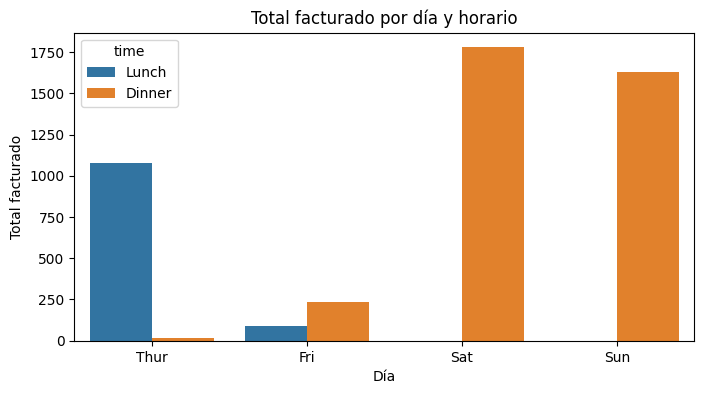

In [ ]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=resumen_dia_horario_grafico,
    x="day",
    y="total_facturado",
    hue="time",
    order=orden_dias
)

plt.title("Total facturado por día y horario")
plt.xlabel("Día")
plt.ylabel("Total facturado")

plt.show()

El gráfico muestra el total facturado según el día y el horario.

La separación por color permite distinguir entre `Lunch` y `Dinner`.

Podemos observar que:

- `Thur` concentra casi toda su facturación en `Lunch`.
- `Fri` tiene facturación en ambos horarios, aunque `Dinner` es mayor que `Lunch`.
- `Sat` y `Sun` aparecen solo en `Dinner`.
- Los valores más altos corresponden a `Sat` y `Sun` en horario de cena.

Este gráfico refuerza algo que ya habíamos visto en la tabla: la facturación no se distribuye de manera pareja entre días y horarios.

También conviene prestar atención a las barras muy pequeñas o ausentes. Por ejemplo, `Thur` tiene una barra mínima en `Dinner` porque solo hay una cuenta registrada en ese horario. En `Sat` y `Sun` no aparece barra para `Lunch` porque no hay registros de almuerzo para esos días en este dataset.

## Leer el argumento `hue`

En el gráfico anterior usamos el argumento `hue`.

La línea principal fue:

```python
sns.barplot(
    data=resumen_dia_horario_grafico,
    x="day",
    y="total_facturado",
    hue="time",
    order=orden_dias
)

```

El argumento `x="day"` indica que los días se ubican en el eje horizontal.

El argumento `y="total_facturado"` indica que la altura de las barras representa el total facturado.

El argumento `hue="time"` agrega una separación por horario. Por eso, dentro de cada día, Seaborn intenta mostrar barras diferentes para `Lunch` y `Dinner`.

Finalmente, `order=orden_dias` fuerza el orden de los días que definimos antes:

`Thur`, `Fri`, `Sat`, `Sun`

Esto es importante porque queremos leer el gráfico respetando el orden temporal básico, no como un ranking.


## Visualizar la cantidad de cuentas por día y horario

El total facturado nos muestra cuánto dinero se acumuló en cada combinación de día y horario. Pero, como vimos antes, ese total depende mucho de la cantidad de cuentas registradas. Por eso vamos a construir un gráfico similar, pero ahora usando `cantidad_cuentas`. La pregunta será:

**¿cuántas cuentas se registraron en cada día y horario?**

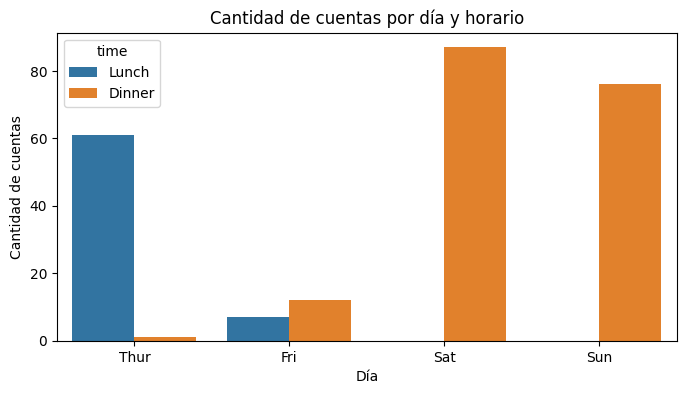

In [ ]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=resumen_dia_horario_grafico,
    x="day",
    y="cantidad_cuentas",
    hue="time",
    order=orden_dias
)

plt.title("Cantidad de cuentas por día y horario")
plt.xlabel("Día")
plt.ylabel("Cantidad de cuentas")

plt.show()

El gráfico muestra la cantidad de cuentas registradas según día y horario.

La lectura visual es bastante clara:

- `Thur` concentra la mayoría de sus cuentas en `Lunch`.
- `Fri` tiene pocas cuentas en ambos horarios, aunque hay más registros en `Dinner`.
- `Sat` y `Sun` concentran sus cuentas en `Dinner`.
- No aparecen barras de `Lunch` para `Sat` y `Sun` porque no hay registros de almuerzo para esos días en el dataset.

Este gráfico ayuda a entender mejor el gráfico anterior de facturación.

Por ejemplo, `Sat` y `Sun` tenían una facturación total alta, pero también son los días con más cuentas en horario de cena. Es decir, el total facturado no depende solamente del importe de cada cuenta, sino también de cuántas cuentas se registraron.

Por eso, cuando hacemos un análisis temporal básico, conviene mirar al menos dos cosas: la cantidad de registros disponibles para cada momento y el valor del indicador que queremos comparar.

## Integrar la lectura

Hasta ahora analizamos los datos desde varias perspectivas:

Primero observamos la cantidad de cuentas por día y horario.

Después calculamos el total facturado y el promedio de cuenta por día.

Luego usamos gráficos de barras para visualizar esas comparaciones.

Lo importante no es elegir una única tabla o un único gráfico, sino combinar varias miradas. Por ejemplo:

`Sat` tiene la mayor cantidad de cuentas y también el mayor total facturado.

`Sun` tiene menos cuentas que `Sat`, pero alcanza el promedio de cuenta más alto.

`Thur` aparece principalmente asociado al almuerzo.

`Fri` tiene pocos registros en comparación con los demás días, por lo que sus resultados deben interpretarse con cuidado.

Esta lectura integrada es parte del análisis exploratorio: mirar los datos desde distintas preguntas antes de sacar conclusiones.

## Cuidado: esto no es una serie temporal completa

Aunque en este capítulo hablamos de análisis temporal básico, es importante hacer una aclaración. Las columnas `day` y `time` nos permiten comparar momentos, pero no tenemos fechas completas. No sabemos a qué semana, mes o año corresponde cada registro. Tampoco sabemos si los datos representan una semana completa, varias semanas o una muestra parcial.

Por eso, con este dataset no podemos hablar de una tendencia histórica. No sería correcto decir, por ejemplo, que “la facturación aumenta con el paso de los días” como si estuviéramos observando una evolución real en el tiempo. Lo que sí podemos decir es más prudente: "en este dataset, las cuentas se distribuyen de manera diferente según el día y el horario"; "`Sat` y `Sun` concentran más facturación en `Dinner`" ;"`Thur` concentra más registros en `Lunch`"; y "algunos promedios deben interpretarse teniendo en cuenta cuántas cuentas los sostienen".

## Cierre del capítulo

En este capítulo empezamos a analizar datos según una dimensión temporal simple.

Trabajamos con las columnas `day` y `time` para observar cómo cambian las cantidades, los totales y los promedios según el momento.

También incorporamos gráficos de barras con Seaborn para visualizar algunos resultados.

Vimos que un gráfico puede ayudar a comparar, pero no reemplaza a la interpretación. Para leer correctamente un gráfico necesitamos saber qué variable aparece en cada eje, qué representa cada barra y cuántos datos hay detrás de cada valor.

Además, distinguimos entre ordenar datos como ranking y respetar un orden temporal. En este capítulo usamos el orden:

`Thur`, `Fri`, `Sat`, `Sun`

Esa decisión nos permitió leer los días como una secuencia y no solo como categorías independientes.

En el próximo capítulo vamos a avanzar hacia otro tipo de visualización: las distribuciones.

Ya no nos vamos a preguntar solamente cómo cambian los datos según un día o un horario, sino cómo se distribuyen los valores de una variable numérica.